In [ ]:
import geopandas as gpd
from geodatasets import get_path
import shapely
from shapely import Polygon, Point
import ee
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

import rasterio
import rioxarray as rxr
from rasterio.warp import calculate_default_transform, reproject, Resampling

from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from shapely import wkt
from rtree import index
from shapely import MultiLineString
import matplotlib

import os
import json
import requests
from shapely.geometry import mapping
from datetime import datetime, timedelta

from dotenv import load_dotenv
load_dotenv
from download_single_image import download_and_validate_async
import random

import planet



PL_API_KEY = os.getenv("PL_API_KEY")

from datetime import datetime

import asyncio
import nest_asyncio
nest_asyncio.apply()
import pyproj
from shapely.ops import transform
from rasterio.plot import reshape_as_image


/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
from planet import Planet


In [3]:
gdf = gpd.GeoDataFrame.from_file(f"gpkgs/haie_2020_france_patches_2024_merged.gpkg", engine='pyogrio', use_arrow=True)
gdf['hedgerows'] = gdf['hedgerows'].replace(['', ' ', 'None', 'null', 'NaN', None, np.nan], pd.NA)

gdf["hedgerows"] = gdf["hedgerows"].apply(
    lambda x: wkt.loads(x) if pd.notna(x) else None
)
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
total_poly = gdf.total_bounds
total_poly = mapping(shapely.geometry.box(total_poly[0], total_poly[1], total_poly[2], total_poly[3]))
total_poly

{'type': 'Polygon',
 'coordinates': (((9.566854742903772, 41.3681624390921),
   (9.566854742903772, 51.0762815067637),
   (-5.093650693926818, 51.0762815067637),
   (-5.093650693926818, 41.3681624390921),
   (9.566854742903772, 41.3681624390921)),)}

In [5]:

planet_url = "https://api.planet.com/data/v1"
start_date = "2020-01-01T00:00:00Z"
end_date = "2020-12-31T23:59:59Z"


plsdk_auth = planet.Auth.from_key(key=PL_API_KEY)
sess = planet.Session(plsdk_auth)

pl = Planet(sess)


In [6]:
from planet import data_filter
def conduct_search(start_date, 
                   end_date, 
                   poly,
                   limit=100,
                   cloud_cover_max=15,
                   light_haze_max=15,
                   clear_percent_min=90,
                   visible_confidence_percent_min=90):
    acquired_filter = data_filter.date_range_filter(
        field_name="acquired",
        gte=datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%SZ"),
        lte=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%SZ")
    )

    updated_filter = data_filter.date_range_filter(
        field_name="acquired",
        gte=datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%SZ"),
        lte=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%SZ")
    )

    or_filter = data_filter.or_filter(
        [
            updated_filter,
            acquired_filter
        ]
    )

    cloud_filter = data_filter.range_filter(
        field_name="cloud_percent",
        lt=cloud_cover_max
    )

    haze_filter = data_filter.range_filter(
        field_name="light_haze_percent",
        lt=light_haze_max
    )

    clear_filter = data_filter.range_filter(
        field_name="clear_percent",
        gt=clear_percent_min
    )

    visible_confidence_filter = data_filter.range_filter(
        field_name="visible_confidence_percent",
        gt=visible_confidence_percent_min
    )

    and_filter = data_filter.and_filter(
        [
            or_filter,
            cloud_filter,
            haze_filter,
            clear_filter,
            visible_confidence_filter
        ]
    )

    retval = pl.data.search(
        item_types=["SkySatScene"],
        search_filter=and_filter,
        geometry=poly,
        limit=limit
    )
    return retval
retval = conduct_search(start_date, end_date, total_poly)
list_retval = list(retval)
len(list_retval)


100

In [7]:
list_retval[0]

{'_links': {'_self': 'https://api.planet.com/data/v1/item-types/SkySatScene/items/20201202_161037_ssc18d2_0025',
  'assets': 'https://api.planet.com/data/v1/item-types/SkySatScene/items/20201202_161037_ssc18d2_0025/assets/',
  'thumbnail': 'https://tiles.planet.com/data/v1/item-types/SkySatScene/items/20201202_161037_ssc18d2_0025/thumb'},
 '_permissions': ['assets.basic_l1a_panchromatic_dn:download',
  'assets.basic_l1a_panchromatic_dn_rpc:download',
  'assets.basic_analytic_dn:download',
  'assets.basic_analytic_dn_rpc:download',
  'assets.basic_analytic_udm:download',
  'assets.basic_panchromatic_dn:download',
  'assets.basic_panchromatic_dn_rpc:download',
  'assets.ortho_visual:download',
  'assets.ortho_analytic_dn:download',
  'assets.ortho_analytic_udm:download',
  'assets.ortho_panchromatic_dn:download',
  'assets.ortho_panchromatic_udm:download',
  'assets.ortho_pansharpened:download',
  'assets.ortho_pansharpened_udm:download',
  'assets.ortho_analytic:download',
  'assets.bas

In [8]:
polys = [shapely.geometry.Polygon(r["geometry"]["coordinates"][0]) for r in list_retval]


In [9]:
import rasterio
import rioxarray as rxr
from rasterio.warp import calculate_default_transform, reproject, Resampling


def to_4326(result,id):
    dst_crs = 'EPSG:4326'

    with rasterio.open(result) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        
        temp_path = f'planet/{id}.byte.wgs84.tif'
        with rasterio.open(temp_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest)
        return temp_path
        

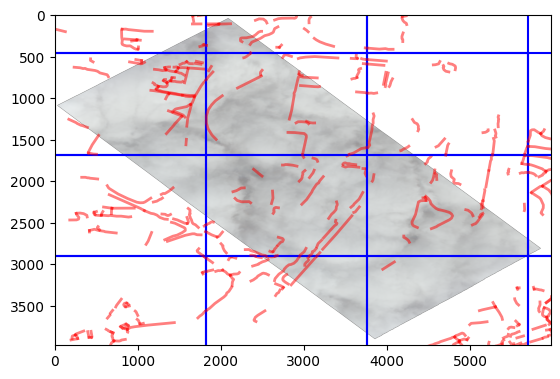

In [10]:
def get_new_xy(x, y, bounds, array):
    l, r, t, b = bounds.left, bounds.right, bounds.top, bounds.bottom
    x_length, y_length = array.shape[1], array.shape[0]
    new_x, new_y = [], []

    for xi, yi in zip(x,y):
        nxi = x_length * ((xi - l) / (r - l))
        nyi = y_length * ((yi - t) / (b - t))

        new_x.append(nxi)
        new_y.append(nyi)

    return new_x, new_y
        
def plot_on_img(gdf, path):
    with rasterio.open(path) as src:
        bounds = src.bounds
        array = reshape_as_image(src.read())
        
    sub_gdf = gdf.cx[bounds.left:bounds.right, bounds.bottom:bounds.top]

    for row in sub_gdf.iterrows():
        geom = row[1]["geometry"]
        x,y = geom.exterior.xy
        new_x, new_y = get_new_xy(x,y,bounds,array)
            
        plt.plot(new_x,new_y,color="blue")

        hedgerows = row[1]["hedgerows"]

        if not hedgerows:
            continue

        try:
            
            for line in hedgerows.geoms:
                hedge_x,hedge_y = line.xy
                new_hedge_x, new_hedge_y = get_new_xy(hedge_x, hedge_y, bounds, array)
        
                plt.plot(new_hedge_x, new_hedge_y, color="red", linewidth=2,alpha=0.5)

        except:
            hedge_x,hedge_y = hedgerows.xy
            new_hedge_x, new_hedge_y = get_new_xy(hedge_x, hedge_y, bounds, array, color="red", linewidth=2,alpha=0.5)
            

    plt.imshow(array)
    plt.show()

plot_on_img(gdf, "test/RGB.byte.wgs84.tif")

In [11]:
def cut_img_to_within_bounds(src, poly):
    if isinstance(src, str):
        src = rasterio.open(src)
    img_bounds = src.bounds
    poly_bounds = poly.bounds
    poly_bounds = rasterio.coords.BoundingBox(poly_bounds[0], poly_bounds[1], poly_bounds[2], poly_bounds[3])

    img = reshape_as_image(src.read())

    img_y = img.shape[0]
    img_x = img.shape[1]

    x_left = int(img_x * max(0, (poly_bounds.left - img_bounds.left) / (img_bounds.right - img_bounds.left)))
    x_right = int(img_x * min(1, (poly_bounds.right - img_bounds.left) / (img_bounds.right - img_bounds.left)))

    y_top = int(img_y * max(0, (img_bounds.top - poly_bounds.top) / (img_bounds.top - img_bounds.bottom)))
    y_bottom = int(img_y * min(1, (img_bounds.top - poly_bounds.bottom) / (img_bounds.top - img_bounds.bottom)))
    
    new_img = img[y_top:y_bottom, x_left:x_right, :].astype(np.float64)
    print(img.shape)
    print(new_img.shape)

    for i in range(new_img.shape[-1]):
        max_val = np.max(new_img[:, :, i])
        if max_val > 0:  
            new_img[:, :, i] /= max_val

    new_left = img_bounds.left + (x_left / img_x) * (img_bounds.right - img_bounds.left)
    new_right = img_bounds.left + (x_right / img_x) * (img_bounds.right - img_bounds.left)
    new_top = img_bounds.top - (y_top / img_y) * (img_bounds.top - img_bounds.bottom)
    new_bottom = img_bounds.top - (y_bottom / img_y) * (img_bounds.top - img_bounds.bottom)
    
    new_bounds = rasterio.coords.BoundingBox(new_left, new_bottom, new_right, new_top)

    return new_img, new_bounds

In [12]:
df = pd.read_csv("csvs/patches_hedgerows_with_iou.csv")

df["geometry"] = df["geometry"].apply(wkt.loads)
df["hedgerows_2024"] = df["hedgerows_2024"].apply(
    lambda x: wkt.loads(x) if pd.notna(x) else None
)
df["hedgerows_2020"] = df["hedgerows_2020"].apply(
    lambda x: wkt.loads(x) if pd.notna(x) else None
)

gdf = gpd.GeoDataFrame(df, crs="EPSG:4326")

floatkeys = ["area_2020", "area_2024", "net_change", "change_rate", "intersection", "union", "iou"]
for k in floatkeys: 
    gdf[k] = gdf[k].astype(float)


In [13]:
gdf["area_change_class"].unique()

array(['new', 'stable', 'removed', 'contracted', 'expanded'], dtype=object)

In [14]:
def take_high_area_sample(gdf, change_class, area_key="area_2024", quantile=0.9, sample_count=None):
    sub = gdf[gdf["area_change_class"] == change_class]
    sub = gdf[gdf[area_key] >= gdf[area_key].quantile(quantile)]
    if sample_count:    
        return sub.sample(sample_count)
    return sub



/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Index(['Unnamed: 0', 'geometry', 'hedgerows_2024', 'hedgerows_2020',
       'area_2020', 'area_2024', 'net_change', 'change_rate',
       'area_change_class', 'intersection', 'union', 'iou',
       'best_results_2020', 'best_results_2024'],
      dtype='object')

Visualizing row 1/5
inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20151129_111908_ss02d1_0010_visual.tif: 100%|██████████| 31.3k/31.3k [00:00<00:00, 47.4MB/s]


inactive
activating
activating
activating
activating
activating
activating
activating
active


20201028_103156_ssc4d1_0008_visual.tif: 100%|██████████| 22.4k/22.4k [00:00<00:00, 47.8MB/s]


(3678, 7875, 4)
(1449, 2005, 4)
(4545, 3441, 4)
(1699, 2349, 4)


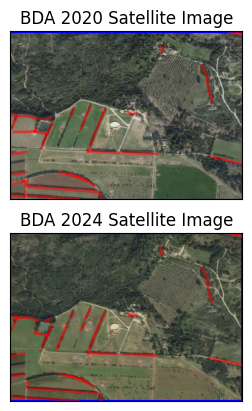


Visualizing row 2/5
inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20151129_111906_ss02d3_0007_visual.tif: 100%|██████████| 30.5k/30.5k [00:00<00:00, 43.9MB/s]


inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20200823_131809_ssc11d3_0011_visual.tif: 100%|██████████| 18.3k/18.3k [00:00<00:00, 45.2MB/s]


(3708, 7801, 4)
(1450, 2007, 4)
(3978, 2438, 4)
(1739, 2328, 4)


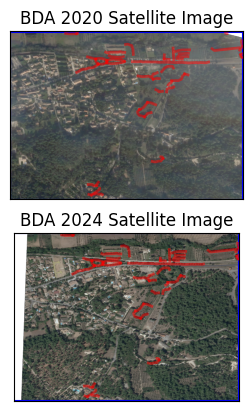


Visualizing row 3/5
inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20151126_112441_ss01d1_0001_visual.tif: 100%|██████████| 1.96k/1.96k [00:00<00:00, 28.0MB/s]


inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20200517_132820_ssc9d1_0003_visual.tif: 100%|██████████| 22.5k/22.5k [00:00<00:00, 46.3MB/s]


(1639, 5763, 4)
(1156, 1760, 4)
(1841, 5197, 4)
(1180, 1796, 4)


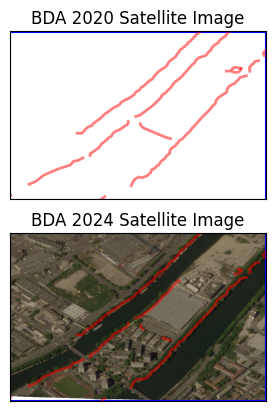


Visualizing row 4/5
inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20150409_102114_ss02d1_0004_visual.tif: 100%|██████████| 27.1k/27.1k [00:00<00:00, 47.4MB/s]


inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20200808_074505_ssc15d1_0005_visual.tif: 100%|██████████| 21.1k/21.1k [00:00<00:00, 56.3MB/s]


(2433, 6980, 4)
(1182, 1798, 4)
(1713, 4620, 4)
(1190, 1358, 4)


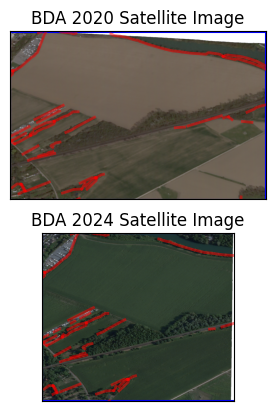


Visualizing row 5/5
inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20150407_113525_ss01d2_0005_visual.tif: 100%|██████████| 21.0k/21.0k [00:00<00:00, 45.8MB/s]


inactive
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
activating
active


20200731_114253_ssc15d1_0020_visual.tif: 100%|██████████| 10.2k/10.2k [00:00<00:00, 50.0MB/s]


(2424, 6692, 4)
(1200, 1819, 4)
(1312, 4220, 4)
(1181, 1769, 4)


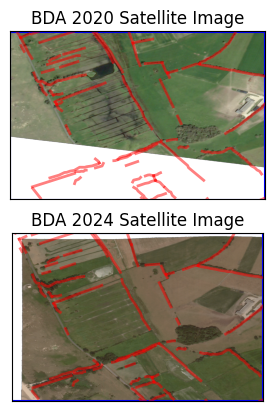

In [15]:
def data_api_results_to_poly(res):
    if isinstance(res, list):
        coords = [obs["geometry"]["coordinates"] for obs in res]
        coords_poly = shapely.geometry.MultiPolygon(coords)
        return coords_poly
    else:
        return shapely.geometry.Polygon(res["geometry"]["coordinates"][0])

def data_result_to_polygon(res):
    return shapely.geometry.Polygon(res["geometry"]["coordinates"][0])



def filter_results_by_overlap(row, results):
    row_poly = row["geometry"]
    filtered_r = [r for r in results if data_api_results_to_poly(r).intersects(row_poly)]
    filtered_r.sort(
        key=lambda x: shapely.intersection(data_api_results_to_poly(x), row_poly).area,
        reverse=True
    )

    return filtered_r


    
def has_large_overlapping_result(row, result_cols, threshold=0.9):
    for col in result_cols:
        res = row[col]
        row_poly = row["geometry"]
        res_poly = data_api_results_to_poly(res)
        
        if (shapely.intersection(row_poly, res_poly).area / row_poly.area) < threshold:
            return False
    return True

async def download_single_image(item_id,item_type_id,asset_type_id):
    session = planet.Session(plsdk_auth)

    path = await download_and_validate_async(session, item_id, asset_type_id, item_type_id)
    result = to_4326(path, id=item_id)
    return result


async def plot_2017_and_2020(row,
                             item_type_id="SkySatScene",
                             asset_type_id="ortho_visual"):
    id_2017 = row["best_results_2020"]["id"]
    id_2020 = row["best_results_2024"]["id"]

    path_2017 = await download_single_image(
        id_2017,
        item_type_id,
        asset_type_id
    )

    path_2020 = await download_single_image(
        id_2020,
        item_type_id,
        asset_type_id
    )

    _, axs = plt.subplots(2,1)

    plot_row_on_img(row, path_2017, ax=axs[0], hedgerows_key = "hedgerows_2020", title="BDA 2020 Satellite Image", show_hedgerows=True)
    plot_row_on_img(row, path_2020, ax=axs[1], hedgerows_key="hedgerows_2024", title="BDA 2024 Satellite Image", show_hedgerows=True)

    plt.show()

def plot_row_on_img(row, path, ax, hedgerows_key = "hedgerows_2020",title="Hedgerows plot", show_hedgerows=True):
    with rasterio.open(path,"r") as src:
    
        poly = row["geometry"]
        x,y = poly.exterior.xy

        array,bounds = cut_img_to_within_bounds(src, poly)
        new_x, new_y = get_new_xy(x,y,bounds,array)

            
        ax.plot(new_x,new_y,color="blue")
        if show_hedgerows:
            hedgerows = row[hedgerows_key]
            try:
                
                for line in hedgerows.geoms:
                    hedge_x,hedge_y = line.xy
                    new_hedge_x, new_hedge_y = get_new_xy(hedge_x, hedge_y, bounds, array)
            
                    ax.plot(new_hedge_x, new_hedge_y, color="red", linewidth=2,alpha=0.5)

            except:
                hedge_x,hedge_y = hedgerows.xy
                new_hedge_x, new_hedge_y = get_new_xy(hedge_x, hedge_y, bounds, array, color="red", linewidth=2,alpha=0.5)
                ax.plot(new_hedge_x, new_hedge_y, color="red", linewidth=2,alpha=0.5)
            

        ax.imshow(array, origin="upper")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])


    
    

async def gdf_visualization(gdf: gpd.GeoDataFrame,
                      year_2020="2015",
                      year_2024="2020",
                      threshold=0.9):
    collective_bounds = shapely.unary_union(
    list(gdf["geometry"])
    )

    start_bda_2020 = f"{year_2020}-01-01T00:00:00Z"
    end_bda_2020 = f"{year_2020}-12-31T00:00:00Z"

    bda_2020_results = conduct_search(start_bda_2020, end_bda_2020, collective_bounds.__geo_interface__, limit=1000)
    bda_2020_results = list(bda_2020_results)

    if len(bda_2020_results) == 0:
        print("No observations found for 2017")
        return
    poly_2020_results = data_api_results_to_poly(bda_2020_results)

    start_bda_2024 = f"{year_2024}-01-01T00:00:00Z"
    end_bda_2024 = f"{year_2024}-12-31T00:00:00Z"

    bda_2024_results = conduct_search(start_bda_2024, end_bda_2024, poly_2020_results.__geo_interface__, limit=1000)
    bda_2024_results = list(bda_2024_results)
    poly_2024_results = data_api_results_to_poly(bda_2024_results)

    overlapping_gdf = gdf[
        gdf.intersects(poly_2020_results) & gdf.intersects(poly_2024_results)
    ]

    best_results_2020 = []
    best_results_2024 = []

    for _, row in overlapping_gdf.iterrows():
        best_results_2020.append(filter_results_by_overlap(row, bda_2020_results)[0])
        best_results_2024.append(filter_results_by_overlap(row, bda_2024_results)[0])

    overlapping_gdf["best_results_2020"] = best_results_2020
    overlapping_gdf["best_results_2024"] = best_results_2024

    print(overlapping_gdf.columns)
    

    overlapping_gdf = overlapping_gdf[overlapping_gdf.apply(lambda x: has_large_overlapping_result(x, ["best_results_2020", "best_results_2024"], threshold=threshold), axis=1)]
    
    if len(overlapping_gdf) == 0:
        print(f"No rows with threshold {threshold}")
        return
    
    overlapping_gdf["result_overlap_2020"] = overlapping_gdf.apply(lambda x: shapely.intersection(data_result_to_polygon(x["best_results_2020"]), x["geometry"]).area, axis=1)
    overlapping_gdf["result_overlap_2024"] = overlapping_gdf.apply(lambda x: shapely.intersection(data_result_to_polygon(x["best_results_2024"]), x["geometry"]).area, axis=1)

    overlapping_gdf["total_overlap"] = overlapping_gdf["result_overlap_2020"] + overlapping_gdf["result_overlap_2024"]

    overlapping_gdf = overlapping_gdf.sort_values(by="total_overlap",ascending=False)
    overlapping_gdf = overlapping_gdf.drop(columns=["total_overlap"])
    
    # Visualize top 9 rows instead of just 1
    num_to_plot = min(9, len(overlapping_gdf))
    for i in range(num_to_plot):
        print(f"\nVisualizing row {i+1}/{num_to_plot}")
        await plot_2017_and_2020(overlapping_gdf.iloc[i])


gdf_stable = take_high_area_sample(gdf, "stable", area_key="area_2020", sample_count=3000, quantile=0.5)
await gdf_visualization(gdf_stable, threshold=0.7)